# nb26 - Inferring the GNFW outer slope beta (arnaudB1 selection, ell>100)

**Updated** to the corrected arnaudB1 pipeline (same data/cov/selection as nb25),
but here **B=1 and sigma_lnY=0.173 are FIXED** and only the GNFW outer slope
**beta** is sampled (broad prior U(3,8)). Other shape params (P0, c500, alpha,
gamma) are the hmfast A10 defaults, cosmology fixed D3A (A_s=2.099e-9). Chains:
`chains/mcmc_arnaudB1_fitBeta_ellgt100/`. Shows the beta posteriors and the
best-fit tSZ spectra against the ell>100 bandpowers.

In [10]:
import os, sys
os.environ["HMFAST_COBAYA_USE_GPU"]="1"; os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
REPO="/scratch/scratch-lxu/flamingo_repo"; sys.path.insert(0,os.path.join(REPO,"cobaya","theory"))
import numpy as np, matplotlib.pyplot as plt, matplotlib.colors as mcolors, jax.numpy as jnp
from getdist import loadMCSamples, plots
from hmfast_tsz_iter_cprofile import _bin_to_18, _ELL_MIN, _ELL_MAX
from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.mass_definition import MassDefinition
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer
from hmfast.tracers.tsz_completeness import build_snr_grid, conditional_An_undetected, load_sigma_y0_curve

In [11]:
CHAIN_DIR=os.path.join(REPO,"chains","mcmc_arnaudB1_fitBeta_ellgt100")
BP_DIR=os.path.join(REPO,"data","bandpowers_arnaudB1"); CV_DIR=os.path.join(REPO,"data","theory_cov_arnaudB1")
KEEP=9; LN1E10_AS=3.044046; SIGMA_LNY=0.173; B_FIX=1.0; BETA_ARNAUD=5.4807
ARN_FIXED=dict(P0=8.13,c500=1.156,alpha=1.062,gamma=0.3292)
A_SZ_SR,ALPHA_SR,B_SR=-4.287396,1.12,1.0
D3A=dict(H0=68.1,omega_cdm=0.118729,omega_b=0.022539,n_s=0.967,tau_reio=0.0544)
CUTS=[("fullsky","Full sky",1.0e9),("qgt5","q > 5",5.0),("qgt10","q > 10",10.0),("qgt20","q > 20",20.0),("qgt50","q > 50",50.0)]
colors=[mcolors.to_hex(c) for c in plt.cm.plasma(np.linspace(0,0.85,len(CUTS)))]
OUTDIR=os.path.join(REPO,"figures","nb26_arnaudB1_fitBeta_ellgt100"); os.makedirs(OUTDIR,exist_ok=True)

## beta posteriors

Full sky beta = 5.999 +/- 0.029 (MAP 5.994)
q > 5    beta = 5.641 +/- 0.006 (MAP 5.639)
q > 10   beta = 5.747 +/- 0.009 (MAP 5.747)
q > 20   beta = 5.839 +/- 0.014 (MAP 5.838)
q > 50   beta = 5.948 +/- 0.027 (MAP 5.946)


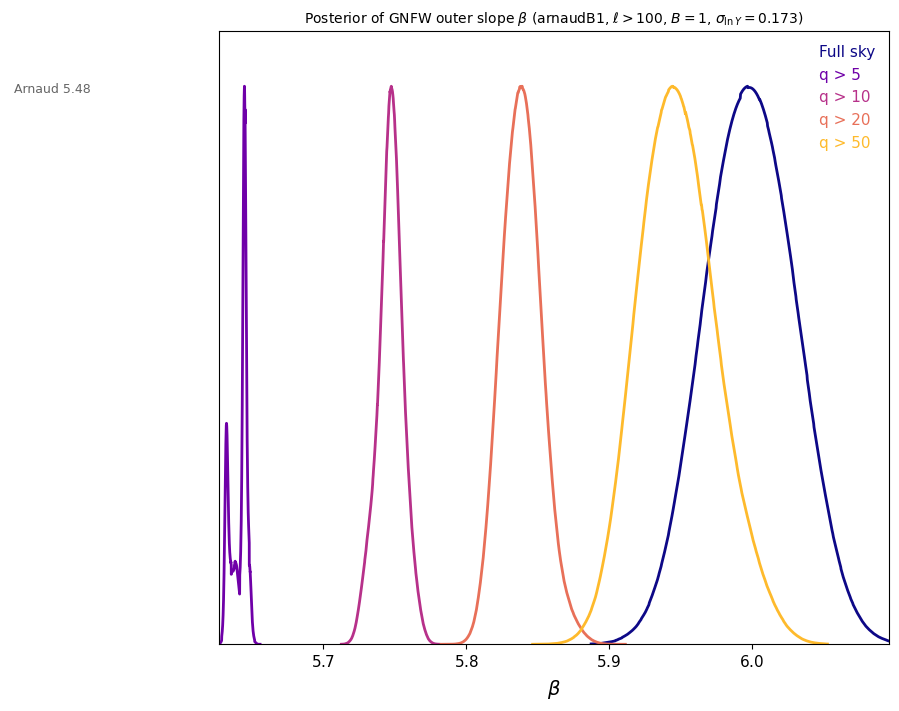

In [12]:
samples,labels,bestfit=[],[],{}
for tag,lab,_ in CUTS:
    s=loadMCSamples(os.path.join(CHAIN_DIR,f"yy_{tag}_fitBeta"),settings={"ignore_rows":0.3})
    s.root=lab; samples.append(s); labels.append(lab)
    b=np.asarray(s.getParams().beta); bestfit[tag]=float(b[int(np.argmin(s.loglikes))])
    print(f"{lab:8s} beta = {s.mean('beta'):.3f} +/- {s.std('beta'):.3f} (MAP {bestfit[tag]:.3f})")
g=plots.get_subplot_plotter(width_inch=7.0); g.settings.legend_fontsize=11
g.plot_1d(samples,"beta",colors=colors); g.add_legend(labels,legend_loc="upper right",colored_text=True)
ax=g.subplots[0,0]; ax.axvline(BETA_ARNAUD,color="0.4",lw=1.0,ls="--",zorder=0)
ax.text(BETA_ARNAUD,ax.get_ylim()[1]*0.9," Arnaud 5.48",color="0.4",fontsize=9)
ax.set_title(r"Posterior of GNFW outer slope $\beta$ (arnaudB1, $\ell>100$, $B=1$, $\sigma_{\ln Y}=0.173$)",fontsize=10)
g.export(os.path.join(OUTDIR,"posterior_beta_arnaudB1_ellgt100.pdf")); g.export(os.path.join(OUTDIR,"posterior_beta_arnaudB1_ellgt100.png")); plt.show()

## hmfast best-fit PS (vary beta, B=1, sigma_lnY=0.173)

In [13]:
m=jnp.geomspace(1e10,10**15.5,64); z=jnp.geomspace(0.005,3.0,96)
ell_int=jnp.geomspace(float(_ELL_MIN[0]),float(_ELL_MAX[-1]),50); ell_np=np.asarray(ell_int)
cosmo=Cosmology(emulator_set="lcdm:v1").update(H0=D3A["H0"],omega_cdm=D3A["omega_cdm"],omega_b=D3A["omega_b"],ln1e10A_s=LN1E10_AS,n_s=D3A["n_s"],tau_reio=D3A["tau_reio"])
hm=HaloModel(cosmology=cosmo,mass_definition=MassDefinition(500,"critical"),convert_masses=True)
prof_seed=GNFWPressureProfile(B=1.0,beta=BETA_ARNAUD,**ARN_FIXED); tsz_seed=tSZTracer(profile=prof_seed)
coeff,_=load_sigma_y0_curve(); snr=build_snr_grid(hm,m,z,A_SZ_SR,ALPHA_SR,B_SR,coeff=coeff)
def predict_dl(q_cat,beta):
    tsz=tsz_seed.update(profile=prof_seed.update(B=B_FIX,beta=beta,**ARN_FIXED))
    mask1=conditional_An_undetected(snr,sigma_lnY=SIGMA_LNY,q_cat=q_cat,n_power=2)
    mask2=conditional_An_undetected(snr,sigma_lnY=SIGMA_LNY,q_cat=q_cat,n_power=1)
    cl1=hm.cl_1h_masked(tsz,None,ell_int,m,z,mask1); cl2=hm.cl_2h_masked(tsz,None,ell_int,m,z,mask2)
    return _bin_to_18(ell_np,np.asarray(cl1))+_bin_to_18(ell_np,np.asarray(cl2))
from scipy.stats import chi2 as _chi2
results={}; print(f"{'cut':8s} {'beta':>7s} {'chi2':>9s} {'dof':>4s} {'PTE':>9s}")
for tag,lab,q_cat in CUTS:
    Dl_full=np.asarray(predict_dl(q_cat,bestfit[tag]))
    D=np.loadtxt(os.path.join(BP_DIR,f"Dl_yy_{tag}_binned_18.txt")); C=np.load(os.path.join(CV_DIR,f"cov_full_{tag}_Dl_yy_binned_18.npy"))
    sl=slice(18-KEEP,18); ell=D[sl,0]; Dl_obs=D[sl,1]; Cs=C[sl,sl]; Dl_th=Dl_full[sl]
    err=np.sqrt(np.diag(Cs)); r=Dl_obs-Dl_th; chi2=float(r@np.linalg.inv(Cs)@r); dof=KEEP-1
    results[tag]=dict(ell=ell,Dl_obs=Dl_obs,err=err,Dl_th=Dl_th)
    print(f"{lab:8s} {bestfit[tag]:7.3f} {chi2:9.2f} {dof:4d} {_chi2.sf(chi2,dof):9.2e}")

cut         beta      chi2  dof       PTE
Full sky   5.994      2.22    8  9.74e-01
q > 5      5.639   1354.84    8 3.29e-287
q > 10     5.747    557.90    8 2.62e-115
q > 20     5.838    282.91    8  1.78e-56
q > 50     5.946     65.06    8  4.69e-11


## Best-fit PS vs bandpowers (ell>100)

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb26_arnaudB1_fitBeta_ellgt100


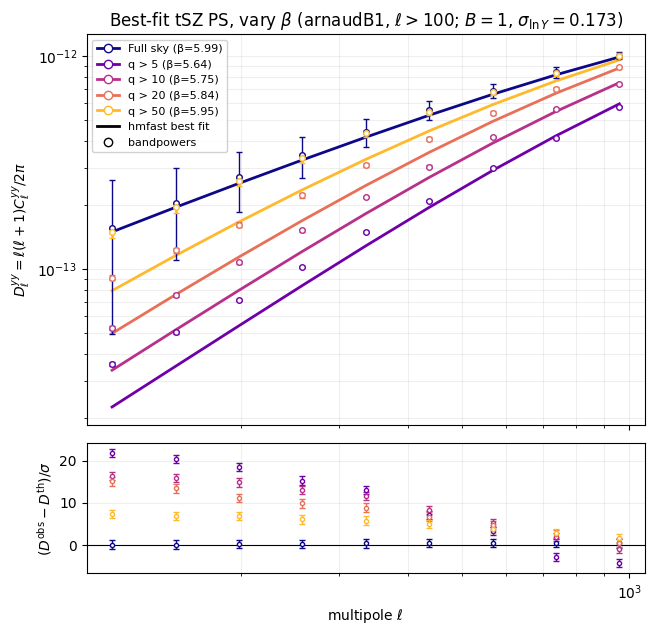

In [14]:
from matplotlib.lines import Line2D
fig,(ax,axr)=plt.subplots(2,1,figsize=(7.2,7.0),sharex=True,gridspec_kw=dict(height_ratios=[3,1],hspace=0.07))
for (tag,lab,_),col in zip(CUTS,colors):
    r=results[tag]
    ax.plot(r["ell"],r["Dl_th"],"-",color=col,lw=2,zorder=3)
    ax.errorbar(r["ell"],r["Dl_obs"],yerr=r["err"],fmt="o",color=col,ms=4,capsize=2,elinewidth=1,mfc="white",zorder=4)
    axr.errorbar(r["ell"],(r["Dl_obs"]-r["Dl_th"])/r["err"],yerr=1.0,fmt="o",color=col,ms=3,capsize=2,elinewidth=1,mfc="white")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylabel(r"$D_\ell^{yy}=\ell(\ell+1)C_\ell^{yy}/2\pi$")
ax.set_title(r"Best-fit tSZ PS, vary $\beta$ (arnaudB1, $\ell>100$; $B=1$, $\sigma_{\ln Y}=0.173$)")
ax.grid(True,which="both",alpha=0.2)
handles=[Line2D([0],[0],color=c,marker="o",mfc="white",lw=2,label=f"{lab} (β={bestfit[tag]:.2f})") for (tag,lab,_),c in zip(CUTS,colors)]
handles+=[Line2D([0],[0],color="k",lw=2,label="hmfast best fit"),Line2D([0],[0],color="k",marker="o",mfc="white",ls="none",label="bandpowers")]
ax.legend(handles=handles,fontsize=8,loc="upper left",framealpha=0.9)
axr.axhline(0,color="k",lw=0.8); axr.set_ylabel(r"$(D^{\rm obs}-D^{\rm th})/\sigma$"); axr.set_xlabel(r"multipole $\ell$"); axr.grid(True,which="both",alpha=0.2)
fig.savefig(os.path.join(OUTDIR,"bestfit_tsz_ps_beta_arnaudB1_ellgt100.png"),dpi=300,bbox_inches="tight")
fig.savefig(os.path.join(OUTDIR,"bestfit_tsz_ps_beta_arnaudB1_ellgt100.pdf"),bbox_inches="tight")
print("saved ->",OUTDIR); plt.show()

## Notes
- B=1, sigma_lnY=0.173 fixed; only beta free. With B=1 (no bias) the amplitude is high, so beta steepens above Arnaud 5.48 to shed power. Full sky fits well; masked cuts poor under the tight Gaussian+trispectrum covariance. dof=9-1.